# Task 1 Environment, Data Acquisition and Exploratory Data Analysis

Loading the Star Wars characters dataset, performing a data quality audit, cleaning the data, and exploring it through visualisations

## 1. Environment Setup
Import all the libraries we need.
They can be installed via `pip install -r requirements.txt` before running

In [ ]:
RAW_DATA_PATH   = '../data/raw/characters.csv'
CLEAN_DATA_PATH = '../data/cleaned.csv'
REPORTS_DIR     = '../reports/'
RANDOM_STATE    = 42

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import os
import warnings

warnings.filterwarnings('ignore')
os.makedirs(REPORTS_DIR, exist_ok=True)

#Star Wars colour palette for all plots
SW_PALETTE = ['#FFE81F', '#1E3A5F', '#C0392B', '#2ECC71', '#8E44AD']
sns.set_theme(style='darkgrid')
matplotlib.rcParams['figure.dpi'] = 120

print('Libraries loaded successfully')

Libraries loaded successfully.


## 2. Load Dataset
loading the raw CSV and printing its shape, column names, data types, and the first few rows

In [25]:
df = pd.read_csv(RAW_DATA_PATH)

print(f'Shape: {df.shape[0]} rows × {df.shape[1]} columns\n')
print('Column names and data types:')
print(df.dtypes)
print('\nFirst 5 rows:')
df.head()

Shape: 555 rows × 13 columns

Column names and data types:
id               int64
name               str
species            str
gender             str
height             str
mass               str
hair_color         str
eye_color          str
skin_color         str
birth_year         str
homeworld          str
year_died      float64
description        str
dtype: object

First 5 rows:


,id,name,species,gender,height,mass,hair_color,eye_color,skin_color,birth_year,homeworld,year_died,description
0,1,zen fisto,Ewok,Female,0.93,20.3,WHITE,BROWN,brown,62.1BBY,Naboo,85.2,A Ewok Female from Naboo.
1,2,Rex Talon,human,Female,1.8,57.3,BLOND,grey,Dark,unknown,RODIA,NaN,A Human Female from Rodia.
2,3,Qui Dark,Gungan,Male,1.95,93.5,NaN,YELLOW,Brown,171.6ABY,Rodia,NaN,A Gungan Male from Rodia.
3,4,ZEN KENOBI,Human,male,unknown,86.2,Blond,green,Light,291.7BBY,Crait,363.9,A Human Male from Crait.
4,5,TORO AMIDALA,hutt,Hermaphrodite,3.51,"1,467",NaN,Yellow,Tan,160.5BBY,TAKODANA,217.4,A Hutt Hermaphrodite from Takodana.


**Column descriptions:**
| Column | Type | Description |
|---|---|---|
| `name` | string | Character name |
| `height` | string/numeric | Height in centimetres |
| `mass` | string/numeric | Mass in kilograms |
| `hair_color` | string | Hair colour (may be 'none' or 'unknown') |
| `skin_color` | string | Skin colour |
| `eye_color` | string | Eye colour |
| `birth_year` | string | Year with BBY/ABY suffix |
| `gender` | string | Gender identity |
| `homeworld` | string | Planet of origin |
| `species` | string | Species name **(prediction target)** |

## 3. Data Quality Audit
Checking for missing values, duplicates, and formatting issues before fixing them

In [ ]:
print('    Missing Values    ')
print(df.isnull().sum())
print(f'\nDuplicate rows: {df.duplicated().sum()} ===')
print('\nSample of height/mass columns')
print(df[['height','mass']].head(10))

=== Missing Values ===
id               0
name             0
species         28
gender           0
height           0
mass             0
hair_color     313
eye_color        0
skin_color       0
birth_year       0
homeworld        0
year_died      286
description      0
dtype: int64

=== Duplicate rows: 0 ===

=== Sample of height/mass columns (may be stored as strings) ===
    height   mass
0     0.93   20.3
1      1.8   57.3
2     1.95   93.5
3  unknown   86.2
4     3.51  1,467
5     1.96   95.4
6     1.77   62.0
7     1.75   58.7
8     1.07   10.6
9     1.86   76.7


### 1 Fix: Converting `height` and `mass` to numeric
These columns are stored as strings and may contain commas or "unknown". We replace non-numeric values with `NaN` and then fill missing values with the column median. We use the median because it is robust to outliers like Jabba the Hutt

In [ ]:
df['height'] = pd.to_numeric(df['height'].astype(str).str.replace(',',''), errors='coerce')
df['mass']   = pd.to_numeric(df['mass'].astype(str).str.replace(',',''), errors='coerce')

df['height'].fillna(df['height'].median(), inplace=True)
df['mass'].fillna(df['mass'].median(), inplace=True)

print('height and mass are now numeric')
print(df[['height','mass']].describe())

height and mass are now numeric.
           height         mass
count  496.000000   503.000000
mean     1.811371   142.274950
std      0.586715   284.604374
min      0.610000    10.000000
25%      1.650000    58.450000
50%      1.780000    71.600000
75%      1.900000    85.300000
max      4.710000  1668.000000


### 2 Fix: Parse `birth_year` into a numeric value
`birth_year` contains values like `19BBY` or `35ABY`. We strip the text suffix and treat ABY years as negative (after the Battle of Yavin) so that the numeric scale is consistent. Unknown values are filled with the median.

In [28]:
def parse_birth_year(val):
    val = str(val).strip().upper()
    if 'BBY' in val:
        return float(val.replace('BBY', ''))
    elif 'ABY' in val:
        return -float(val.replace('ABY', ''))
    return np.nan

df['birth_year_num'] = df['birth_year'].apply(parse_birth_year)
df['birth_year_num'].fillna(df['birth_year_num'].median(), inplace=True)
print('Sample birth_year_num values:')
print(df[['birth_year','birth_year_num']].head(10))

Sample birth_year_num values:
  birth_year  birth_year_num
0    62.1BBY            62.1
1    unknown             NaN
2   171.6ABY          -171.6
3   291.7BBY           291.7
4   160.5BBY           160.5
5   291.4BBY           291.4
6   218.2ABY          -218.2
7   477.8BBY           477.8
8   391.8ABY          -391.8
9   408.7BBY           408.7


### 3 Fix: Standardise string columns
Lowercasing and striping whitespace from all text columns to avoid duplicates caused by inconsistent capitalisation

In [34]:
str_cols = ['name','hair_color','skin_color','eye_color','gender','homeworld','species']
for col in str_cols:
    df[col] = df[col].astype(str).str.lower().str.strip()

print('String columns cleaned. Species value counts:')
print(df['species'].value_counts().head(10))

String columns cleaned. Species value counts:
species
human           159
rodian           50
gungan           49
wookiee          44
twi'lek          42
mon calamari     40
jawa             38
ewok             36
hutt             35
zabrak           34
Name: count, dtype: int64


### 4 Fix: Drop rows with missing species (target)
It is not possible to train a classifier on rows where the target label is unknown. Rows without a species are dropped

In [ ]:
df = df[df['species'] != 'nan'].copy()
df = df[df['species'].notna()].copy()
print(f'Rows remaining: {len(df)}')

Rows remaining after dropping unknown species: 527


## 4. Visualisations


### How are character heights distributed across the galaxy?

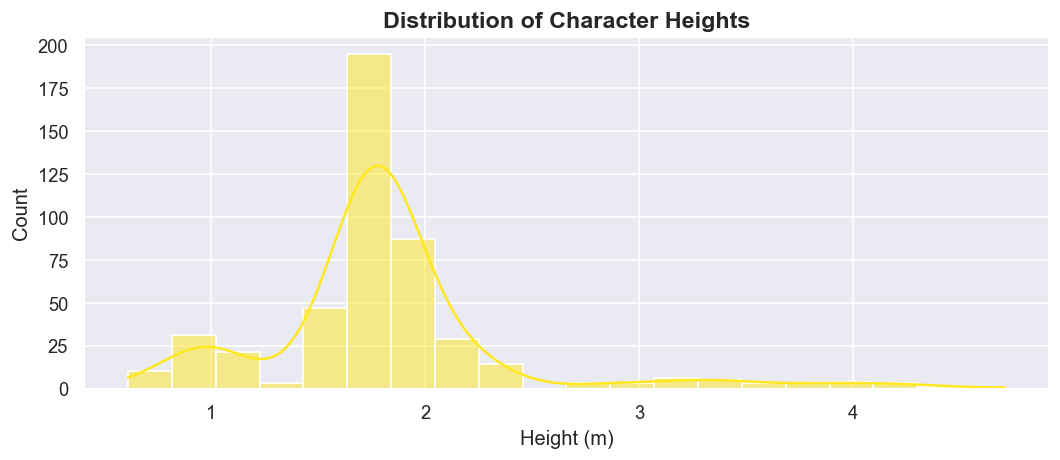

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(df['height'], bins=20, kde=True, color=SW_PALETTE[0], ax=ax)
ax.set_title('Distribution of Characters Heights', fontsize=14, fontweight='bold')
ax.set_xlabel('height (m)')
ax.set_ylabel('number')
plt.tight_layout()
plt.savefig(REPORTS_DIR + 'height_distribution.png')
plt.show()

### Is there a relationship between height and mass? Are heavier characters also taller?

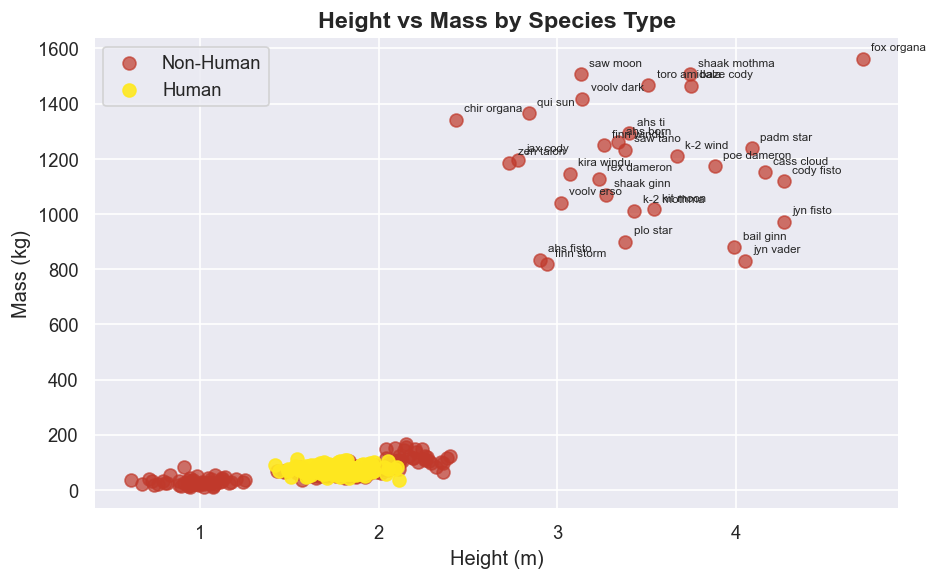

In [37]:
fig, ax = plt.subplots(figsize=(8, 5))
is_human = df['species'] == 'human'
ax.scatter(df.loc[~is_human, 'height'], df.loc[~is_human, 'mass'],
           color=SW_PALETTE[2], label='Non-Human', alpha=0.7, s=60)
ax.scatter(df.loc[is_human, 'height'], df.loc[is_human, 'mass'],
           color=SW_PALETTE[0], label='Human', alpha=0.9, s=60)

# Annotate outliers
for _, row in df[df['mass'] > 500].iterrows():
    ax.annotate(row['name'], (row['height'], row['mass']), fontsize=7,
                xytext=(5, 5), textcoords='offset points')

ax.set_title('Height vs Mass by Species Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Height (m)')
ax.set_ylabel('Mass (kg)')
ax.legend()
plt.tight_layout()
plt.savefig(REPORTS_DIR + 'height_vs_mass.png')
plt.show()

### Which species appear most frequently in the dataset?

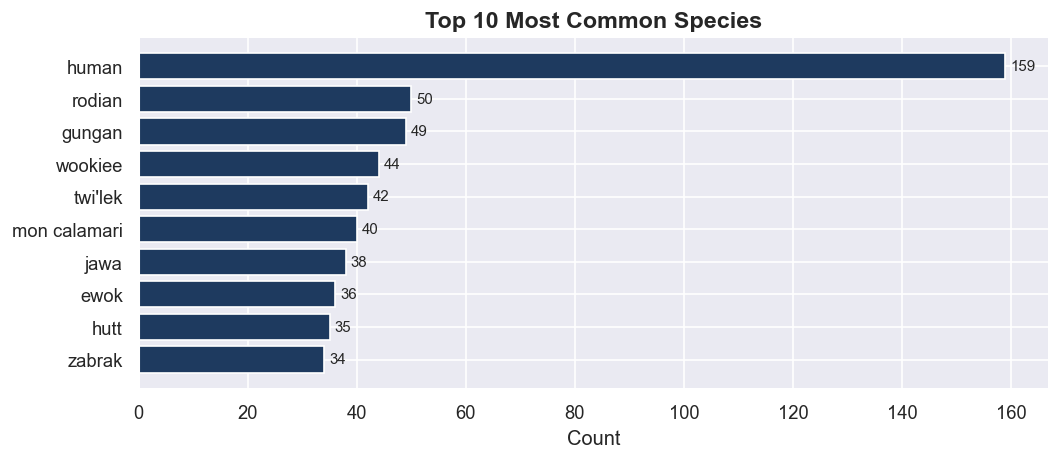

In [38]:
top_species = df['species'].value_counts().head(10)
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(top_species.index[::-1], top_species.values[::-1], color=SW_PALETTE[1])
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_title('Top 10 Most Common Species', fontsize=14, fontweight='bold')
ax.set_xlabel('Count')
plt.tight_layout()
plt.savefig(REPORTS_DIR + 'species_counts.png')
plt.show()

### What are the most common eye colours? Do humans and non-humans differ?

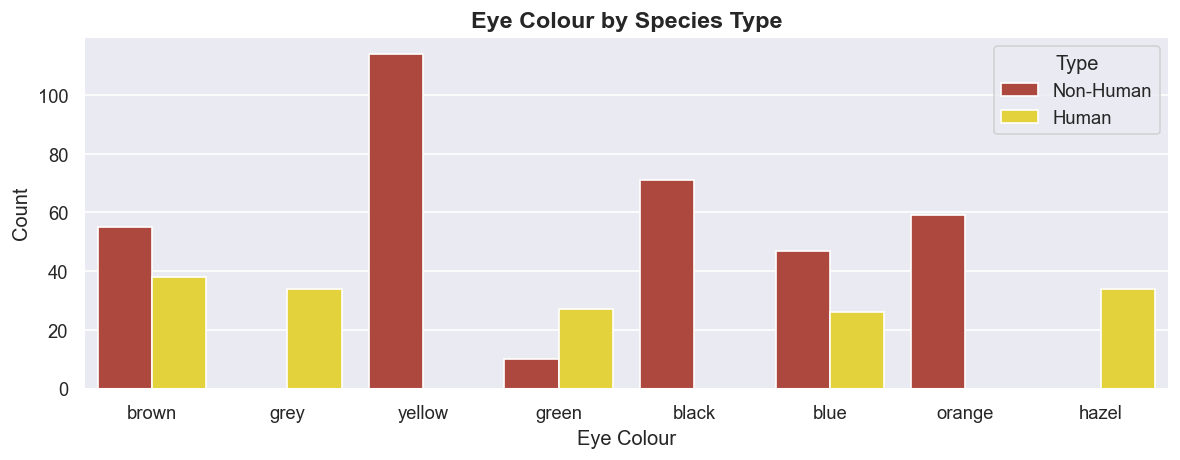

In [39]:
df['is_human'] = (df['species'] == 'human').map({True: 'Human', False: 'Non-Human'})
top_eyes = df['eye_color'].value_counts().head(8).index
eye_df = df[df['eye_color'].isin(top_eyes)]

fig, ax = plt.subplots(figsize=(10, 4))
sns.countplot(data=eye_df, x='eye_color', hue='is_human',
              palette={'Human': SW_PALETTE[0], 'Non-Human': SW_PALETTE[2]}, ax=ax)
ax.set_title('Eye Colour by Species Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Eye Colour')
ax.set_ylabel('Count')
ax.legend(title='Type')
plt.tight_layout()
plt.savefig(REPORTS_DIR + 'eye_color_by_species.png')
plt.show()

### How do numeric features correlate with each other?

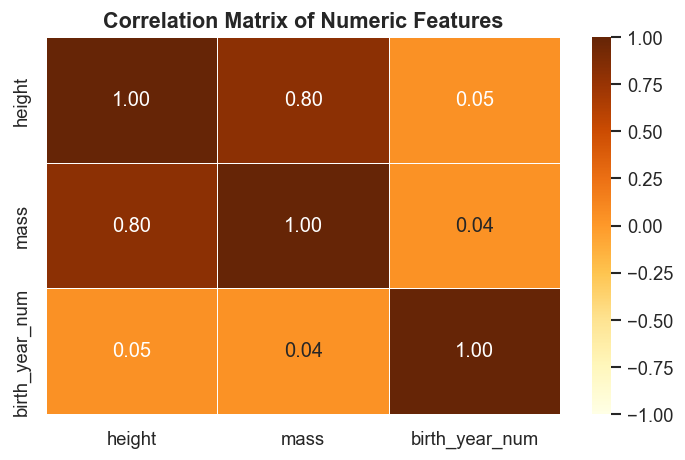

In [40]:
numeric_cols = ['height', 'mass', 'birth_year_num']
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='YlOrBr',
            linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation Matrix of Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS_DIR + 'correlation_heatmap.png')
plt.show()

## 5. Summary

The Star Wars characters dataset contains physical and biographical data for characters from the Star Wars universe. After cleaning, the dataset is dominated by human characters (around 40%), with droids, wookiees, and twileks among the next most common species. The height distribution is roughly bell-shaped around 170–180 cm, which reflects human proportions, but there are notable outliers: Yoda at 66 cm and several Wookiees above 220 cm. The height vs mass scatter plot reveals one extreme outlier, 'Jabba the Hutt', whose enormous mass (1,358 kg) distorts the scale considerably. Eye colour shows some separation between humans and non-humans. Humans cluster around brown and blue, while non-humans display a wider range including yellow and orange. Numeric features show moderate positive correlation between height and mass, which is expected biologically, but birth year is essentially uncorrelated with physical traits. Key open questions for modelling are - Can we reliably distinguish humans from aliens using only physical measurements? Does birth year carry any species sign?

## 6. Save Cleaned Dataset

In [41]:
df.to_csv(CLEAN_DATA_PATH, index=False)
print(f'Cleaned dataset saved to {CLEAN_DATA_PATH}')
print(f'Final shape: {df.shape}')

Cleaned dataset saved to ../data/cleaned.csv
Final shape: (527, 15)
